# VAERS GROUP EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import scipy.stats as stats

from pathlib import Path

### Prebuilt functions

In [ ]:
## IRQ Functions for outliers - created these during lab_02_todo
def get_iqr_upper(x):
    return x.quantile(0.75)+(1.5*(x.quantile(0.75)-x.quantile(0.25)))

def get_iqr_lower(x):
    iqr_low = x.quantile(0.25)-(1.5*(x.quantile(0.75)-x.quantile(0.25)))
    if iqr_low < 0:
        return 0
    else:
        return iqr_low

### Loads .csv into a frame

In [12]:
# Reads .csv of all data included in VAERS Kaggle dataset.
df_data_raw = pd.read_csv("data/VAERSDATA.csv")
df_symp_raw = pd.read_csv("data/VAERSSYMPTOMS.csv")
df_vax_raw = pd.read_csv("data/VAERSVAX.csv")
#NOTE: A warning will appear about the DType of some columns. This is because when reading the .csv, assumptions are made about what the data types are for some columns when storing into a dataframe (and those assumptions conflict with the actual observations in the column itself). I will make corrections to these later on so please just ignore this warning if it appears.

C:\Users\sbzav\AppData\Local\Temp\ipykernel_14780\984576542.py:2: DtypeWarning: Columns (0: RPT_DATE, 1: ER_VISIT, 2: X_STAY, 3: V_FUNDBY) have mixed types. Specify dtype option on import or set low_memory=False.
  df_data_raw = pd.read_csv("data/VAERSDATA.csv")


In [13]:
## Resets dataframe without having to reload the CSV into the frame. Noticed this saves a couple of seconds if a reset is needed. Code will not work if this cell isn't ran.
df_data = df_data_raw
df_symp = df_symp_raw
df_vax = df_vax_raw

### Pre-Cleaning Inspection "Vibe Check"

In [ ]:
## Columns and quick peak at first 10 columns
# Set ""dataset" variable to proper integer to show details about specific .csv

# 0 = df_data | 1 = df_symp | 2 = df_vax
dataset = 0

if dataset == 0:
    df_data.info()
    df_data.head(10)
    #for i in df_data.columns:
        #print(f'\n{df_data[i].unique()}')
elif dataset == 1:
    df_symp.info()
    df_symp.head(10)
    #for i in df_symp.columns:
        #print(f'\n{df_symp[i].unique()}')
elif dataset == 2:
    print(df_vax.info())
    print(df_vax.head(10))
    #for i in df_vax.columns:
        #print(f'\n{df_vax[i].unique()}')

### Cleaning
I will be using the following [data dictionary](https://vaers.hhs.gov/docs/VAERSDataUseGuide_November2020.pdf) to help with my cleaning of the data.

#### General Cleaning
This section focuses on removing true duplicate records. It does not include cases where the same VAERS_ID appears with differing information in other columns, since those represent legitimate follow‑up entries in df_date (VAXDATA.csv). Instead, this serves as a broad space for universal cleaning steps that apply across datasets. For the purposes of this EDA, that simply means eliminating accidental duplicate reports. If future EDA is required for any other particular reasons (i.e., visualization), it will also be included in this section.

In [ ]:
### Removing Duplicates

In [ ]:
## DF_DATA
print("\ndf_data")
print(f"\n{df_data["VAERS_ID"].value_counts()}")
print(f"\n{df_data.duplicated().sum()}")
print(f"\n{df_data.shape}")
# NOTE: This doesn't have duplicate rows. Printed data will show that.

In [ ]:
## DF_SYMP
print("\ndf_symp")
print(f"\n{df_symp["VAERS_ID"].value_counts()}")
print(f"\n{df_symp.duplicated().sum()}")
print(f"\n{df_symp.shape}")
# NOTE: This doesn't have duplicate rows. Printed data will show that.

In [ ]:
## DF_VAX
# Checking for duplicates
print("\ndf_vax")
print(f"\n{df_vax["VAERS_ID"].value_counts()}")
print(f"\n{df_vax.duplicated().sum()}")
df_temp = df_vax[df_vax["VAERS_ID"] == 2523925] # Example of a duplicate to look at.
df_temp.head(19)

In [14]:
# Removing identified duplicates
df_vax.drop_duplicates(inplace=True) # removes the identified duplicate rows.
print(f"Number of duplicates remaining: {df_vax.duplicated().sum()}")

# New function(s) learned:
# .duplicates() https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.duplicated.html

# NOTE: Essentially, DF_VAX is just a dataframe that logs which vaccine type was given to each person tied to a VAERS_ID. With that in mind, the duplicates I flagged are basically saying something like, “Hey, Bob apparently got multiple Moderna Covid19 shots, with no way to differentiate them.” Since there’s no date or timestamp to separate these entries, and every column is identical row by row, the most reasonable assumption is that they’re accidental repeats. That’s why I’m removing them. My guess is they were just copied into the dataset more than once by mistake.

Number of duplicates remaining: 0


#### DF_VAX Cleaning
This step removes outliers in the number of doses recorded for a vaccination and standardizes categorical fields such as vaccine name and administration site. Most variables in DF_VAX function as independent variables and may be used to predict symptom‑related outcomes (see DF_VAX section). The cleanings here focus on specific columns within DF_VAX (VAERSVAX.csv). In particular, we are going to try and clean up some of the names of our categorical variables, while also removing any NULLS using naming conventions for unknown observations as outlined in the [VAERS data dictionary](https://vaers.hhs.gov/docs/VAERSDataUseGuide_November2020.pdf).

In [15]:
### Fixing VAX_NAME
## Simplifying names, removing COVID19 moniker redundancy (VAX_TYPE indicates that all recorded vaccinations are for COVID19 anyway).
df_vax['VAX_NAME'] = df_vax['VAX_NAME'].str.replace('COVID19 (COVID19 (PFIZER-BIONTECH))','PFIZER-BIONTECH')
df_vax['VAX_NAME'] = df_vax['VAX_NAME'].str.replace('COVID19 (COVID19 (UNKNOWN))','UNKNOWN')
df_vax['VAX_NAME'] = df_vax['VAX_NAME'].str.replace('COVID19 (COVID19 (JANSSEN))','JANSSEN')
df_vax['VAX_NAME'] = df_vax['VAX_NAME'].str.replace('COVID19 (COVID19 (MODERNA))','MODERNA')
df_vax['VAX_NAME'] = df_vax['VAX_NAME'].str.replace('COVID19 (COVID19 (MODERNA BIVALENT))','MODERNA BIVALENT')
df_vax['VAX_NAME'] = df_vax['VAX_NAME'].str.replace('COVID19 (COVID19 (PFIZER-BIONTECH BIVALENT))','PFIZER-BIONTECH BIVALENT')
df_vax['VAX_NAME'] = df_vax['VAX_NAME'].str.replace('COVID19 (COVID19 (NOVAVAX))','NOVAVAX')
print(f'New names: \n{df_vax['VAX_NAME'].unique()}')

New names: 
<StringArray>
[         'PFIZER-BIONTECH',                  'UNKNOWN',
                  'MODERNA',                  'JANSSEN',
         'MODERNA BIVALENT', 'PFIZER-BIONTECH BIVALENT',
                  'NOVAVAX']
Length: 7, dtype: str


In [16]:
df_vax['VAX_DOSE_SERIES'].value_counts()

VAX_DOSE_SERIES
1      448928
2      284875
UNK    169387
3      106597
4       38475
5       15724
6        2085
7+        669
Name: count, dtype: int64

In [26]:
### Fixing VAX_DOSE_SERIES
## Converting to integer64 data type, as the variable identifies how many vaccinations are required per dose. Having any decimal points wouldn't make sense for this type of information.
#df_vax = df_vax.dropna(axis=0, subset=['VAX_DOSE_SERIES'])
df_vax['VAX_DOSE_SERIES'] = df_vax['VAX_DOSE_SERIES'].str.replace("7+","7") # There are 669 values that are 7 or above. That is 0.06% of the total doses (without dropping any nulls or NaNs).
df_vax = df_vax[df_vax['VAX_DOSE_SERIES'].str.contains('UNK') == False]
df_vax['VAX_DOSE_SERIES'] = df_vax['VAX_DOSE_SERIES'].astype('Int64')
# Figure out why UNKs / blanks are not showing Int64 value_counts()
print(df_vax['VAX_DOSE_SERIES'].value_counts())
print(f"Values that are null: {df_vax['VAX_DOSE_SERIES'].isnull().sum()}")

VAX_DOSE_SERIES
1    448928
2    284875
3    106597
4     38475
5     15724
6      2085
7       669
Name: count, dtype: Int64
Values that are null: 4825


In [18]:
### Fixing VAX_ROUTE & _SITE
## Converting nulls/empty observations to UN (UN stands for "unknown" and is redundant with these NAs). This is a specific observation that the VAERS dataset uses to identify missing information. Going to copy it one-to-one to stay consistent.
df_vax.fillna({'VAX_ROUTE':"UN"}, inplace = True)
df_vax.fillna({'VAX_SITE':"UN"}, inplace = True)
print(f"Values that are null: {df_vax['VAX_ROUTE'].isnull().sum()}")
print(f"Values that are null: {df_vax['VAX_SITE'].isnull().sum()}")

Values that are null: 0
Values that are null: 0


In [23]:
### VAX LOT
## Removing column as VAX_LOT is not currently needed for our visualizations. I also have no clue what it is, I'm not gonna lie. Feel free to scope the reflection at the end since I talk about it there.

## ARCHIVE: Old code showing some of the process utilized for cleaning VAX_LOT.
print(df_vax['VAX_LOT'].unique())
df_vax['VAX_LOT'] = df_vax['VAX_LOT'].str.strip() # removes whitespace on outside of string if prevalent.
df_vax['VAX_LOT'] = df_vax['VAX_LOT'].str.replace(" ","")
df_vax['VAX_LOT'] = df_vax['VAX_LOT'].str.upper()
print(f"Values that are null: {df_vax['VAX_LOT'].isnull().sum()}")

VAX_LOT
039K20A     5448
013L20A     4859
026L20A     4504
011J20A     4032
EK9231      3677
            ... 
OR14289        1
CVS88600       1
8059263        1
8062765        1
2041123A       1
Name: count, Length: 39613, dtype: int64

In [ ]:
### CONFIRMATION OF CLEANING FOR DATAFRAME
print(df_vax.info())
print(df_vax.head(10))

In [24]:
## SAVING A COPY FOR SAFE KEEPING AND FUTURE USE
filepath = Path("data/VAERS_Vax/Vax_Cleaned.csv")
filepath.parent.mkdir(parents=True, exist_ok=True)
df_vax.to_csv(filepath, index=False)

<class 'pandas.DataFrame'>
Index: 902178 entries, 0 to 1073514
Data columns (total 8 columns):
 #   Column           Non-Null Count   Dtype
---  ------           --------------   -----
 0   VAERS_ID         902178 non-null  int64
 1   VAX_TYPE         902178 non-null  str  
 2   VAX_MANU         902178 non-null  str  
 3   VAX_LOT          679604 non-null  str  
 4   VAX_DOSE_SERIES  897353 non-null  Int64
 5   VAX_ROUTE        902178 non-null  str  
 6   VAX_SITE         902178 non-null  str  
 7   VAX_NAME         902178 non-null  str  
dtypes: Int64(1), int64(1), str(6)
memory usage: 62.8 MB
None

                    count            mean            std       min  \
VAERS_ID         902178.0  1716542.265721  543318.523616  902418.0   
VAX_DOSE_SERIES  897353.0        1.769852       0.975257       1.0   

                        25%        50%         75%        max  
VAERS_ID         1232038.25  1640442.5  2160999.75  2776312.0  
VAX_DOSE_SERIES         1.0        1.0         2.0   

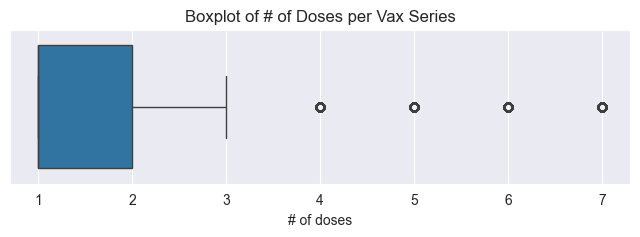

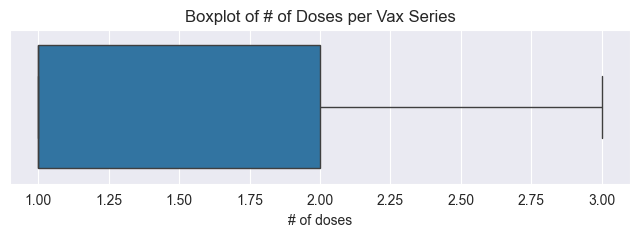

In [27]:
## CHECKING FOR & REMOVING OUTLIERS
# Getting descriptive statistics of outliers for VAX_DOSE_SERIES
print(f'{df_vax.info()}\n')
print(df_vax.describe(percentiles=[0.25,0.5,0.75]).T)
print(f'\nUpper IQR: {get_iqr_upper(df_vax['VAX_DOSE_SERIES'])}\n')

# Boxplot for VAX_DOSE_SERIES (visualizing outliers for VAX_DOSE_SERIES)
plt.figure(figsize= (8,2))
ax = sns.boxplot(data = df_vax, x= df_vax['VAX_DOSE_SERIES'])
ax.set_xlabel('# of doses',fontsize = 10)
ax.set_title('Boxplot of # of Doses per Vax Series', fontsize= 12)
plt.ticklabel_format(style='plain', axis='x')

# Dropping outliers - creating new DF that contains version of df_vax w/o int64 outliers. The get_iqr_upper function calculates upper bound of column and removes observations from outside that upper bound.
df_vax_noliers = df_vax[df_vax['VAX_DOSE_SERIES']<(get_iqr_upper(df_vax['VAX_DOSE_SERIES']))]
print(f'\n{df_vax_noliers.info()}\n')
# NOTE: I am removing outliers from these as it seems bizarre to have COVID19 dose requirements in the 4-7 range. I could see it being possible, but again, it looks to fall outside the range of the typical.

# Boxplot for VAX_DOSE_SERIES (visualizing VAX_DOSE_SERIES w/o outliers)
plt.figure(figsize= (8,2))
ax = sns.boxplot(data = df_vax_noliers, x= df_vax_noliers['VAX_DOSE_SERIES'])
ax.set_xlabel('# of doses',fontsize = 10)
ax.set_title('Boxplot of # of Doses per Vax Series', fontsize= 12)
plt.ticklabel_format(style='plain', axis='x')

In [ ]:
## SAVING A COPY FOR SAFE KEEPING AND FUTURE USE
filepath = Path("data/VAERS_Vax/Vax_Cleaned_NoOutliers.csv")
filepath.parent.mkdir(parents=True, exist_ok=True)
df_vax_noliers.to_csv(filepath, index=False)

#### DF_SYMPTOMS Cleaning
This section forms the foundation of our analysis. Because our goal is to understand potential adverse effects and identify symptom trends, all symptom variables here function as dependent variables. Our goal is to try and predict how the most frequent symptoms change based on a variety of factors prevalent in the other datasets. To speak broadly, every other column beyond symptoms are our potential independent variables that would like to use to try and predict symptoms. Though for the purpose of EDA, we are just going to explore how we can condense down the many columns of symptoms into something easily quantifiable, and we will get a rough idea of the overall "most frequent" symptoms that onset from COVID19 vaccination. The cleanings focus on specific columns in DF_SYMP (VAERSSYMPTOMS.csv).

In [41]:
### CREATING A DATAFRAME AND .CSV THAT SIMPLIFIES COUNTING MOST COMMON SYMPTOMS
## Separating each recorded symptom column into a unique dataframe.

print(f'\n{df_symp.info()}')

df_symp1 = df_symp[['VAERS_ID','SYMPTOM1']]
df_symp1.rename(columns={'SYMPTOM1':'SYMPTOM'}, inplace=True)
#print(f"Remaining values that are null for Symptom1: {df_symp_all['SYMPTOM'].isnull().sum()}")
#print(f'\n{df_symp_all.info()}')

df_symp2 = df_symp[['VAERS_ID','SYMPTOM2']]
df_symp2.dropna(axis=0, subset=['SYMPTOM2'], inplace=True)
df_symp2.rename(columns={'SYMPTOM2':'SYMPTOM'}, inplace=True)
#print(f"Remaining values that are null for Symptom2: {df_symp2['SYMPTOM'].isnull().sum()}")
#print(f'\n{df_symp2.info()}')

df_symp3 = df_symp[['VAERS_ID','SYMPTOM3']]
df_symp3.dropna(axis=0, subset=['SYMPTOM3'], inplace=True)
df_symp3.rename(columns={'SYMPTOM3':'SYMPTOM'}, inplace=True)
#print(f"Remaining values that are null for Symptom3: {df_symp3['SYMPTOM'].isnull().sum()}")
#print(f'\n{df_symp3.info()}')

df_symp4 = df_symp[['VAERS_ID','SYMPTOM4']]
df_symp4.dropna(axis=0, subset=['SYMPTOM4'], inplace=True)
df_symp4.rename(columns={'SYMPTOM4':'SYMPTOM'}, inplace=True)
#print(f"Remaining values that are null for Symptom4: {df_symp4['SYMPTOM'].isnull().sum()}")
#print(f'\n{df_symp4.info()}')

df_symp5 = df_symp[['VAERS_ID','SYMPTOM5']]
df_symp5.dropna(axis=0, subset=['SYMPTOM5'], inplace=True)
df_symp5.rename(columns={'SYMPTOM5':'SYMPTOM'}, inplace=True)
#print(f"Remaining values that are null for Symptom5: {df_symp5['SYMPTOM'].isnull().sum()}")
#print(f'\n{df_symp5.info()}')

## New functions learned and other comments.
# Rename() https://www.geeksforgeeks.org/pandas/how-to-rename-columns-in-pandas-dataframe/
# Concat() https://pandas.pydata.org/docs/reference/api/pandas.concat.html

# NOTE 1: I would typically create a for loop to reduce the code length, however, I don't have time. Am just going to do this manual.
# NOTE 2: Symptom version numbers are dropped from this dataframe and for the purpose of this analysis. Goal is just to give a general idea to stakeholders on possible symptoms. For instance, the definition of a headache slightly changing would not necessarily change the fact that it is currently the most commonly reported symptom.
# NOTE 2: From my understanding of the dataset, some patients can have more symptoms than the columns offered. This would explain duplicate VAERS_ID with different symptoms logged. One symptom, like headaches, could be logged across different columns, meaning you need to stack the columns to accurately count the frequency of specific symptoms.

<class 'pandas.DataFrame'>
RangeIndex: 1363171 entries, 0 to 1363170
Data columns (total 11 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   VAERS_ID         1363171 non-null  int64  
 1   SYMPTOM1         1363171 non-null  str    
 2   SYMPTOMVERSION1  1363171 non-null  float64
 3   SYMPTOM2         1044702 non-null  str    
 4   SYMPTOMVERSION2  1044702 non-null  float64
 5   SYMPTOM3         792563 non-null   str    
 6   SYMPTOMVERSION3  792563 non-null   float64
 7   SYMPTOM4         600471 non-null   str    
 8   SYMPTOMVERSION4  600471 non-null   float64
 9   SYMPTOM5         458415 non-null   str    
 10  SYMPTOMVERSION5  458415 non-null   float64
dtypes: float64(5), int64(1), str(5)
memory usage: 114.4 MB

None


In [42]:
## COMBINES SYMPTOM DATAFRAMES INTO ONE SINGLE DATAFRAME (a.k.a STACKING THE TABLES)
df_symp_all = pd.concat([df_symp1,df_symp2,df_symp3,df_symp4,df_symp5])
print(df_symp_all.info(show_counts=True))

<class 'pandas.DataFrame'>
Index: 4259322 entries, 0 to 1363157
Data columns (total 2 columns):
 #   Column    Non-Null Count    Dtype
---  ------    --------------    -----
 0   VAERS_ID  4259322 non-null  int64
 1   SYMPTOM   4259322 non-null  str  
dtypes: int64(1), str(1)
memory usage: 97.5 MB
None


In [43]:
## CREATING UNIQUE DATAFRAME FOR FUTURE VISUALIZATION USE
df_symp_all_counts = df_symp_all['SYMPTOM'].value_counts()
df_symp_top100 = df_symp_all_counts.head(100)
df_symp_top100.to_frame('COUNT').reset_index()

## New functions learned and other comments.
# .to_frame() & .reset_index() https://stackoverflow.com/questions/28503445/assigning-column-names-to-a-pandas-series

,SYMPTOM,COUNT
0,Headache,153304
1,Pyrexia,133057
2,Fatigue,132705
3,Pain,109623
4,Chills,107362
...,...,...
95,Herpes zoster,8026
96,Feeling cold,8016
97,Somnolence,7983
98,Full blood count,7968


In [ ]:
## SAVING A COPY FOR SAFE KEEPING AND FUTURE USE
filepath = Path("data/VAERS_Symp/Symp_All.csv")
filepath.parent.mkdir(parents=True, exist_ok=True)
df_symp_all.to_csv(filepath, index=False)

filepath = Path("data/VAERS_Symp/Symp_All_Top100.csv")
filepath.parent.mkdir(parents=True, exist_ok=True)
df_symp_top100.to_csv(filepath)

#### DF_DATA Cleaning
This cleaning step is too detailed to describe column by column, however, the in-line comments outline the main transformations. In short, we cleaned additional variables that serve as independent predictors for understanding common symptoms. For example, AGE_YRS could be a natural independent variable for predicting the most common adverse effects reported from vaccination, showing a positive correlation or not. You will also see many boolean fields created to support filtering in the dashboard, allowing stakeholders to explore how symptom patterns change for groups such as individuals who identify as disabled, those with allergies, or those with relevant medical histories. The cleanings here focus on specific columns in DF_DATA (VAERSDATA.csv).

In [28]:
### FIXING DTYPES
print(f'Before changes are made: \n{df_data.info()}')

<class 'pandas.DataFrame'>
RangeIndex: 1012894 entries, 0 to 1012893
Data columns (total 35 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   VAERS_ID      1012894 non-null  int64  
 1   RECVDATE      1012894 non-null  str    
 2   STATE         842425 non-null   str    
 3   AGE_YRS       909608 non-null   float64
 4   CAGE_YR       809314 non-null   float64
 5   CAGE_MO       5374 non-null     float64
 6   SEX           1012894 non-null  str    
 7   RPT_DATE      1130 non-null     str    
 8   SYMPTOM_TEXT  1011423 non-null  str    
 9   DIED          18951 non-null    str    
 10  DATEDIED      16828 non-null    str    
 11  L_THREAT      15197 non-null    str    
 12  ER_VISIT      144 non-null      str    
 13  HOSPITAL      90081 non-null    str    
 14  HOSPDAYS      53040 non-null    float64
 15  X_STAY        505 non-null      str    
 16  DISABLE       18274 non-null    str    
 17  RECOVD        882224 non-null   str   

In [29]:
## Dates - Decided to keep all the dates for now. I want to explore viz options with my team before removing any; will help to better understand how certain recorded dates could change the way we see general information about possible side effects of vax overtime (or even how they change overtime).
df_data['RECVDATE'] = pd.to_datetime(df_data['RECVDATE'], format='%m/%d/%Y')
df_data['RPT_DATE'] = pd.to_datetime(df_data['RPT_DATE'], format='%m/%d/%Y')
df_data['DATEDIED'] = pd.to_datetime(df_data['DATEDIED'], format='%m/%d/%Y')
df_data['VAX_DATE'] = pd.to_datetime(df_data['VAX_DATE'], format='%m/%d/%Y')
df_data['ONSET_DATE'] = pd.to_datetime(df_data['ONSET_DATE'], format='%m/%d/%Y')
df_data['TODAYS_DATE'] = pd.to_datetime(df_data['TODAYS_DATE'], format='%m/%d/%Y')

In [30]:
## Floats -> Integer (Int64 allows for nulls. These columns don't make sense to have any decimal points).
df_data['AGE_YRS'] = df_data['AGE_YRS'].round(decimals=0)
df_data['AGE_YRS'] = df_data['AGE_YRS'].astype('Int64')
df_data['HOSPDAYS'] = df_data['HOSPDAYS'].round(decimals=0)
df_data['HOSPDAYS'] = df_data['HOSPDAYS'].astype('Int64')
df_data['NUMDAYS'] = df_data['NUMDAYS'].round(decimals=0)
df_data['NUMDAYS'] = df_data['NUMDAYS'].astype('Int64')

In [31]:
## Dropped - Separated to indicate reasoning line-by-line.
df_data.drop(columns=['CAGE_YR','CAGE_MO'], inplace=True) # Redundant with AGE_YRS. We aren't solely focused on specific demographics w/in an age.
df_data.drop(columns=['SYMPTOM_TEXT'], inplace=True) # Redundant with VAERS_Symp. I don't see the need to word cloud this w/ VAERS_Symp already filled out.
df_data.drop(columns=['LAB_DATA'], inplace=True) # Qual. data on lab visit reasoning. Not necessarily needed for viz work; no plans for word cloud.
df_data.drop(columns=['SPLTTYPE'], inplace=True) # Type of vax, and the manufacturer, are already recorded in VAERSVAX.csv. VAERS_ID links that info.
df_data.drop(columns=['FORM_VERS'], inplace=True) # The version of the report system isn't relevant to symptom frequencies.

In [32]:
## Bool - I think these could be helpful as filters. How exactly would frequent symptoms change if one of these bools is true or false.

# Confident in accuracy of
df_data['DIED'] = df_data['DIED'].replace(np.nan,False)
df_data['DIED'] = df_data['DIED'].astype('bool') # Have people died after a vaccination was reported? Can we actually draw a connection here?
df_data['L_THREAT'] = df_data['L_THREAT'].replace(np.nan,False)
df_data['L_THREAT'] = df_data['L_THREAT'].astype('bool') # Do those with life-threatening illnesses report different symptoms?
df_data['HOSPITAL'] = df_data['HOSPITAL'].replace(np.nan,False)
df_data['HOSPITAL'] = df_data['HOSPITAL'].astype('bool') # Are those who are hospitalized have any specific types of symptoms?
df_data['X_STAY'] = df_data['X_STAY'].replace(np.nan,False)
df_data['X_STAY'] = df_data['X_STAY'].astype('bool') # Do those with life-threatening illnesses report different symptoms?
df_data['DISABLE'] = df_data['DISABLE'].replace(np.nan,False)
df_data['DISABLE'] = df_data['DISABLE'].astype('bool') # Do those who identify as disabled report different symptoms?
df_data['BIRTH_DEFECT'] = df_data['BIRTH_DEFECT'].replace(np.nan,False)
df_data['BIRTH_DEFECT'] = df_data['BIRTH_DEFECT'].astype('bool') # Was a birth defect or congenital anomaly recorded at time of vax? What symptoms showed up?

# Unconfident in accuracy - WILL NEED FURTHER CLEANING AFTER THIS FIRST INITIAL EDA - SEE REFLECTION AT END OF REPORT FOR MORE DETAIL
df_data['CUR_ILL'] = df_data['CUR_ILL'].notnull() # Do reported illnesses at time of vax change the most common symptoms?
df_data['HISTORY'] = df_data['HISTORY'].notnull() # Does having any form of recorded history change what freq. symptoms show up?
df_data['ALLERGIES'] = df_data['ALLERGIES'].notnull()  # Does having an allergy change the types of symptoms that are reported?
df_data['OTHER_MEDS'] = df_data['OTHER_MEDS'].notnull()  # Can being on medication change the symptoms or adverse side effects that appear from vax?
df_data['PRIOR_VAX'] = df_data['PRIOR_VAX'].notnull()  # Can being on medication change the symptoms or adverse side effects that appear from vax?

# NOTE: For the string/open-ended columns, I’m converting these fields to simple True/False flags because building a full keyword-based tagging system is out of scope for this class (as discussed with prof). Booleans still let me filter and compare symptom patterns based on whether these conditions show up, which is enough for the dashboard work I’m doing. The tricky part is that NULL means “no record,” but some non‑null entries are basically text versions of “none". Cleaning all of that in a reliable way would take more time and bandwidth than I have, and doing it perfectly would probably require a language model. So for now, I’m leaving the raw text as it is, and converting the columns to booleans. I will make sure to note this in our dashboard so our clients/stakeholders are aware of this caveat when viewing the eventual visualizations.

In [33]:
## Keeping as string, specific cleaning instructions regarding NULLS provided by data dictionary
df_data.fillna({'RECOVD':"U"}, inplace = True) # Data of unknown status of vaccine recovery is in column already. Just replacing NULLS with "U"
df_data.fillna({'V_ADMINBY':"UNK"}, inplace = True) # Location of administration specifies an "Unknown" observation. Just replacing NULLS with "UNK"
df_data.fillna({'V_FUNDBY':"OTH"}, inplace = True) # Specifies that purchase history can be Other/Unknown. Just replacing NULLS with "OTH"
# ^ make blanks UNK or U instead of OTH

## New functions learned and other comments.
# .notnull() https://pandas.pydata.org/docs/reference/api/pandas.notnull.html
# .astype(bool) is stupid https://www.reddit.com/r/learnpython/comments/1mokeww/the_insidious_astypebool/

,VAERS_ID,RECVDATE,STATE,AGE_YRS,SEX,RPT_DATE,DIED,DATEDIED,L_THREAT,ER_VISIT,...,V_FUNDBY,OTHER_MEDS,CUR_ILL,HISTORY,PRIOR_VAX,TODAYS_DATE,BIRTH_DEFECT,OFC_VISIT,ER_ED_VISIT,ALLERGIES
0,902418,2020-12-15,NJ,56,F,NaT,False,NaT,False,NaN,...,OTH,True,True,True,False,2020-12-15,False,NaN,NaN,True
1,902440,2020-12-15,AZ,35,F,NaT,False,NaT,False,NaN,...,OTH,False,False,False,False,2020-12-15,False,NaN,NaN,False
2,902446,2020-12-15,WV,55,F,NaT,False,NaT,False,NaN,...,OTH,True,True,True,False,2020-12-15,False,NaN,NaN,True
3,902464,2020-12-15,LA,42,M,NaT,False,NaT,False,NaN,...,OTH,True,True,True,False,2020-12-15,False,NaN,Y,True
4,902465,2020-12-15,AR,60,F,NaT,False,NaT,False,NaN,...,OTH,True,True,True,False,2020-12-15,False,NaN,NaN,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1012889,2776307,2024-06-27,DC,<NA>,F,NaT,False,NaT,False,NaN,...,OTH,False,False,True,False,2024-06-26,False,NaN,NaN,False
1012890,2776309,2024-06-27,NaN,<NA>,U,NaT,False,NaT,False,NaN,...,OTH,False,False,False,False,2024-06-27,False,NaN,NaN,False
1012891,2776310,2024-06-27,NaN,66,F,NaT,False,NaT,False,NaN,...,OTH,False,False,False,False,2024-06-27,False,NaN,NaN,False
1012892,2776312,2024-06-27,FL,<NA>,U,NaT,False,NaT,False,NaN,...,OTH,False,False,False,False,2024-06-26,False,NaN,NaN,False


In [34]:
## Double-checks dtype changes and verifies that bools actually became bools. The as.type(bool) function is finicky.
print(f'After changes are made: \n{df_data.info()}')
print(f'{df_data['DIED'].value_counts()}\n')
print(f'{df_data['L_THREAT'].value_counts()}\n')
print(f'{df_data['X_STAY'].value_counts()}\n')
print(f'{df_data['DISABLE'].value_counts()}\n')
print(f'{df_data['BIRTH_DEFECT'].value_counts()}\n')
print(f'{df_data['CUR_ILL'].value_counts()}\n')
print(f'{df_data['HISTORY'].value_counts()}\n')
print(f'{df_data['ALLERGIES'].value_counts()}\n')
print(f'{df_data['OTHER_MEDS'].value_counts()}\n')
print(f'{df_data['PRIOR_VAX'].value_counts()}\n')

<class 'pandas.DataFrame'>
RangeIndex: 1012894 entries, 0 to 1012893
Data columns (total 29 columns):
 #   Column        Non-Null Count    Dtype         
---  ------        --------------    -----         
 0   VAERS_ID      1012894 non-null  int64         
 1   RECVDATE      1012894 non-null  datetime64[us]
 2   STATE         842425 non-null   str           
 3   AGE_YRS       909608 non-null   Int64         
 4   SEX           1012894 non-null  str           
 5   RPT_DATE      1130 non-null     datetime64[us]
 6   DIED          1012894 non-null  bool          
 7   DATEDIED      16828 non-null    datetime64[us]
 8   L_THREAT      1012894 non-null  bool          
 9   ER_VISIT      144 non-null      str           
 10  HOSPITAL      1012894 non-null  bool          
 11  HOSPDAYS      53040 non-null    Int64         
 12  X_STAY        1012894 non-null  bool          
 13  DISABLE       1012894 non-null  bool          
 14  RECOVD        1012894 non-null  str           
 15  VAX_DATE 

In [35]:
## SAVING A COPY FOR SAFE KEEPING AND FUTURE USE
#PRec = Patient Record
filepath = Path("data/VAERS_Data/PRec_Cleaned.csv")
filepath.parent.mkdir(parents=True, exist_ok=True)
df_data.to_csv(filepath, index=False)

In [ ]:
## CHECKING FOR & REMOVING OUTLIERS

<class 'pandas.DataFrame'>
RangeIndex: 1012894 entries, 0 to 1012893
Data columns (total 29 columns):
 #   Column        Non-Null Count    Dtype         
---  ------        --------------    -----         
 0   VAERS_ID      1012894 non-null  int64         
 1   RECVDATE      1012894 non-null  datetime64[us]
 2   STATE         842425 non-null   str           
 3   AGE_YRS       909608 non-null   Int64         
 4   SEX           1012894 non-null  str           
 5   RPT_DATE      1130 non-null     datetime64[us]
 6   DIED          1012894 non-null  bool          
 7   DATEDIED      16828 non-null    datetime64[us]
 8   L_THREAT      1012894 non-null  bool          
 9   ER_VISIT      144 non-null      str           
 10  HOSPITAL      1012894 non-null  bool          
 11  HOSPDAYS      53040 non-null    Int64         
 12  X_STAY        1012894 non-null  bool          
 13  DISABLE       1012894 non-null  bool          
 14  RECOVD        1012894 non-null  str           
 15  VAX_DATE 

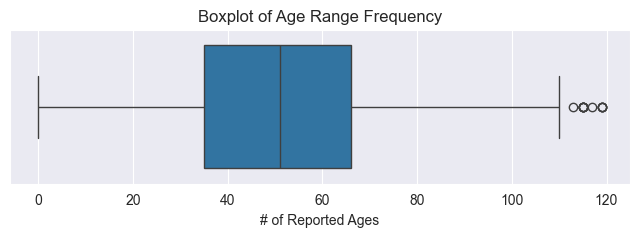

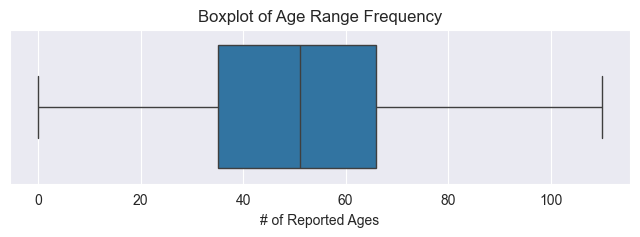

In [36]:
# Getting descriptive statistics of outliers for AGE_YRS
print(f'{df_data.info()}\n')
print(df_data.describe(percentiles=[0.25,0.5,0.75]).T)
print(f'\nUpper IQR: {get_iqr_upper(df_data['AGE_YRS'])}\n')

# Boxplot for AGE_YRS (visualizing outliers for AGE_YRS
plt.figure(figsize= (8,2))
ax = sns.boxplot(data = df_data, x= df_data['AGE_YRS'])
ax.set_xlabel('# of Reported Ages', fontsize = 10)
ax.set_title('Boxplot of Age Range Frequency', fontsize= 12)
plt.ticklabel_format(style='plain', axis='x')

# Dropping outliers - creating new DF that contains version of df_data w/o int64 outliers for age (but still includes nulls of age). The get_iqr_upper function calculates upper bound of column and removes observations from outside that upper bound. The OR statement is intential as to keep blanks for the purpose of filtering lateron. For instance, if I only want to focus on people with information on their age, then I'd need to know who doesn't have an age to filter out of the symptoms dataframe.
df_data_noliers = df_data[(df_data['AGE_YRS']<(get_iqr_upper(df_data['AGE_YRS']))) | (df_data['AGE_YRS'].isnull())]
print(f'\n{df_data_noliers.info()}\n')
# NOTE: I am removing outliers from this section because some people are very very old, which is impressive in its own right, but outside the typical average range of ages for those vaccinated.

# Boxplot for AGE_YRS (visualizing AGE_YRS w/o outliers)
plt.figure(figsize= (8,2))
ax = sns.boxplot(data = df_data_noliers, x= df_data_noliers['AGE_YRS'])
ax.set_xlabel('# of Reported Ages', fontsize = 10)
ax.set_title('Boxplot of Age Range Frequency', fontsize= 12)
plt.ticklabel_format(style='plain', axis='x')

<class 'pandas.DataFrame'>
RangeIndex: 1012894 entries, 0 to 1012893
Data columns (total 29 columns):
 #   Column        Non-Null Count    Dtype         
---  ------        --------------    -----         
 0   VAERS_ID      1012894 non-null  int64         
 1   RECVDATE      1012894 non-null  datetime64[us]
 2   STATE         842425 non-null   str           
 3   AGE_YRS       909608 non-null   Int64         
 4   SEX           1012894 non-null  str           
 5   RPT_DATE      1130 non-null     datetime64[us]
 6   DIED          1012894 non-null  bool          
 7   DATEDIED      16828 non-null    datetime64[us]
 8   L_THREAT      1012894 non-null  bool          
 9   ER_VISIT      144 non-null      str           
 10  HOSPITAL      1012894 non-null  bool          
 11  HOSPDAYS      53040 non-null    Int64         
 12  X_STAY        1012894 non-null  bool          
 13  DISABLE       1012894 non-null  bool          
 14  RECOVD        1012894 non-null  str           
 15  VAX_DATE 

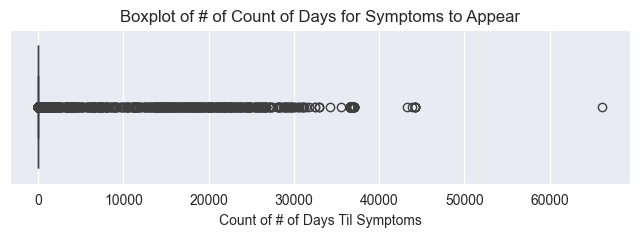

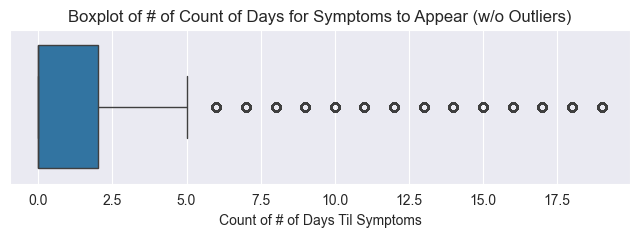

In [37]:
# Getting descriptive statistics of outliers for NUMDAYS
print(f'{df_data.info()}\n')
print(df_data.describe(percentiles=[0.25,0.5,0.75]).T)
print(f'\nUpper IQR: {get_iqr_upper(df_data['NUMDAYS'])}\n')

# Boxplot for NUMDAYS (visualizing outliers for NUMDAYS
plt.figure(figsize= (8,2))
ax = sns.boxplot(data = df_data, x= df_data['NUMDAYS'])
ax.set_xlabel('Count of # of Days Til Symptoms', fontsize = 10)
ax.set_title('Boxplot of # of Count of Days for Symptoms to Appear', fontsize= 12)
plt.ticklabel_format(style='plain', axis='x')

# Dropping outliers - adding to existing DF that contains version of df_data w/o int64 outliers for NUMDAYS (but still includes nulls of NUMDAYS). The get_iqr_upper function calculates upper bound of column and removes observations from outside that upper bound. The OR statement is intential as to keep blanks for the purpose of filtering lateron. For instance, if I only want to focus on people with information on the number of days it took them to get symptoms, then I'd need to know who we haven't recorded days for.
df_data_noliers = df_data_noliers[(df_data_noliers['NUMDAYS']<(get_iqr_upper(df_data_noliers['NUMDAYS']))) | (df_data_noliers['NUMDAYS'].isnull())]
print(f'\n{df_data_noliers.info()}\n')
# NOTE: For some reason, we have absurd time ranges for how long it took for onset of symptoms to appear for vaccination. With that in mind, I got rid of those "absurdly long" days it took til symptoms from the dataset.

# Boxplot for NUMDAYS (visualizing NUMDAYS w/o outliers)
plt.figure(figsize= (8,2))
ax = sns.boxplot(data = df_data_noliers, x= df_data_noliers['NUMDAYS'])
ax.set_xlabel('Count of # of Days Til Symptoms', fontsize = 10)
ax.set_title('Boxplot of # of Count of Days for Symptoms to Appear (w/o Outliers)', fontsize= 12)
plt.ticklabel_format(style='plain', axis='x')

<class 'pandas.DataFrame'>
RangeIndex: 1012894 entries, 0 to 1012893
Data columns (total 29 columns):
 #   Column        Non-Null Count    Dtype         
---  ------        --------------    -----         
 0   VAERS_ID      1012894 non-null  int64         
 1   RECVDATE      1012894 non-null  datetime64[us]
 2   STATE         842425 non-null   str           
 3   AGE_YRS       909608 non-null   Int64         
 4   SEX           1012894 non-null  str           
 5   RPT_DATE      1130 non-null     datetime64[us]
 6   DIED          1012894 non-null  bool          
 7   DATEDIED      16828 non-null    datetime64[us]
 8   L_THREAT      1012894 non-null  bool          
 9   ER_VISIT      144 non-null      str           
 10  HOSPITAL      1012894 non-null  bool          
 11  HOSPDAYS      53040 non-null    Int64         
 12  X_STAY        1012894 non-null  bool          
 13  DISABLE       1012894 non-null  bool          
 14  RECOVD        1012894 non-null  str           
 15  VAX_DATE 

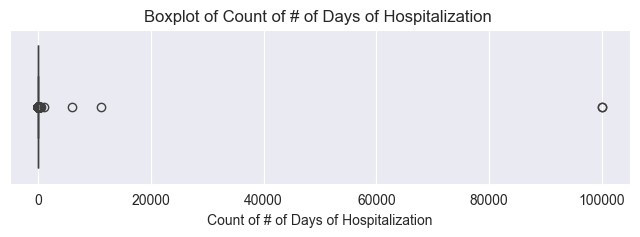

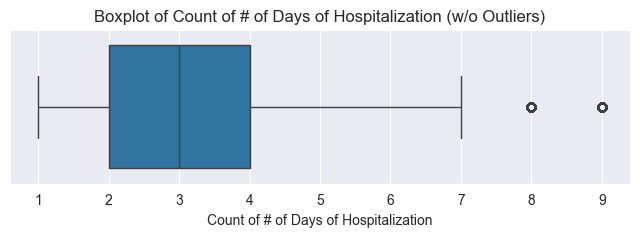

In [38]:
# Getting descriptive statistics of outliers for HOSPDAYS
print(f'{df_data.info()}\n')
print(df_data.describe(percentiles=[0.25,0.5,0.75]).T)
print(f'\nUpper IQR: {get_iqr_upper(df_data['HOSPDAYS'])}\n')

# Boxplot for HOSPDAYS (visualizing outliers for HOSPDAYS
plt.figure(figsize= (8,2))
ax = sns.boxplot(data = df_data, x= df_data['HOSPDAYS'])
ax.set_xlabel('Count of # of Days of Hospitalization', fontsize = 10)
ax.set_title('Boxplot of Count of # of Days of Hospitalization ', fontsize= 12)
plt.ticklabel_format(style='plain', axis='x')

# Dropping outliers - adding to existing DF that contains version of df_data w/o int64 outliers for HOSPDAYS (but still includes nulls of HOSPDAYS). The get_iqr_upper function calculates upper bound of column and removes observations from outside that upper bound. The OR statement is intential as to keep blanks for the purpose of filtering lateron.
df_data_noliers = df_data_noliers[(df_data_noliers['HOSPDAYS']<(get_iqr_upper(df_data_noliers['HOSPDAYS']))) | (df_data_noliers['HOSPDAYS'].isnull())]
print(f'\n{df_data_noliers.info()}\n')
# NOTE: For some reason, we have absurd time ranges for how long they were hospitalized. I basically just removed any absurdly long prolonged hospital experiences.

# Boxplot for HOSPDAYS (visualizing HOSPDAYS w/o outliers)
plt.figure(figsize= (8,2))
ax = sns.boxplot(data = df_data_noliers, x= df_data_noliers['HOSPDAYS'])
ax.set_xlabel('Count of # of Days of Hospitalization', fontsize = 10)
ax.set_title('Boxplot of Count of # of Days of Hospitalization (w/o Outliers)', fontsize= 12)
plt.ticklabel_format(style='plain', axis='x')

In [39]:
## SAVING A COPY FOR SAFE KEEPING AND FUTURE USE
filepath = Path("data/VAERS_Data/PRec_Cleaned_NoOutliers.csv")
filepath.parent.mkdir(parents=True, exist_ok=True)
df_data_noliers.to_csv(filepath, index=False)

### Correlations
Due to scope and time, I decided to focus on two types of correlation/relationship style visualizations: 1) a heatmap studying the correlation between common symptoms, and 2) a scatterplot studying the correlation between symptom onset and hospitalization stay length. In short, I wasn't able to find any strong correlation within any of the pairings. Those results and how I got to them can be found in this section.

In [ ]:
### SYMPTOMS-RELATED

In [ ]:
## Heatmap studying relationship between top 5 - 10 symptoms

In [44]:
# Reconfirming most frequent symptoms
print(df_symp_all_counts.head(20))
# Note: Some of the symptoms in the top 100 aren't really symptoms or are redundant. I'm going to take some liberties when deciding what is top 10 or not in the following cell blocks.

SYMPTOM
Headache                        153304
Pyrexia                         133057
Fatigue                         132705
Pain                            109623
Chills                          107362
COVID-19                         90551
Nausea                           83442
Pain in extremity                82445
Dizziness                        81690
SARS-CoV-2 test positive         59446
Myalgia                          58816
Dyspnoea                         53982
Arthralgia                       53229
Injection site pain              46897
Rash                             43894
Expired product administered     41072
Pruritus                         39543
Product storage error            38675
Asthenia                         37865
Vomiting                         37608
Name: count, dtype: int64


In [45]:
# Grabbing the most common symptoms and putting them into a dataframe with their VAERS_ID

# NOTE: This section is kind of confusion, and a little all over the place, so I'm going to explain everything line-by-line/

# Top 10 - Overall
Top_10_Symp_Dict = {'Headache','Pyrexia','Fatigue','Pain','Chills','Nausea','Myalgia','Dyspnoea','Arthralgia','Rash'} # this needs to be a dictionary to filter out other symptoms from a general symptoms list we made earlier.
Top_10_Symp = list(Top_10_Symp_Dict) # for some reason, I need to convert this back into a list to make this functional with my For Loop

symp_all_top10 = df_symp_all[df_symp_all['SYMPTOM'].isin(Top_10_Symp_Dict)] # This creates a new dataframe that only consists of my top 10 symptoms
symp_all_top10.drop_duplicates(inplace=True) # For some reason, I have duplicates where a VAERS_ID may report the same symptom. I'm going to go ahead and remove this since we just need to know if someone had a headache at some point, and now hoy many times they reported one.
symp_all_top10_tf = symp_all_top10[['VAERS_ID']] # This creates a new dataframe holding the VAERS_ID of those who have any of the top 10 symptoms.
symp_all_top10_tf.drop_duplicates(inplace=True) # This drops and duplicate VAERS_ID that might still be there, it's precautionary if for some reason the previous drop didn't work.

# This function basically just takes a symptom, turns it into a column, then essentially marks whether a specific VAERS_ID reported having that symptom. This mark mimics a float that mimics bool-like behavior. This is done to study the linear relationship between symptoms for the purpose of correlations / heatmapping.
for i in Top_10_Symp:
    symp_all_top10_tf[i] = symp_all_top10[symp_all_top10['SYMPTOM'] == i]['SYMPTOM']
    symp_all_top10_tf[i] = symp_all_top10_tf[i].replace({np.nan:0, i:1})

## Learned
# .isin()
# - https://www.reddit.com/r/learnpython/comments/qqrq62/how_to_use_strcontains_to_get_exact_matches_and/
# - https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isin.html#pandas.DataFrame.isin

## Note to self: .merge() will be helpful in filtering out specific VAERS_ID from df_symp_all (i.e., maybe I want to look at people who only have allergies and how their most commonly reported adverse side effects change). Depending on what my team wants to explore for the final project, I will explore messing with that. For time and scope reasons, I'm just going to leave it at exploring the overall most common symptoms and adverse side effects, and save my use of the .merge() function for another time. Again, this is just a note to self for future use.

In [46]:
# Top 10 Pearson & Spearman Correlations
print(f'Pearson Correlation:\n {symp_all_top10_tf.corr(method='pearson')}\n')
print(f'Spearman Correlation:\n {symp_all_top10_tf.corr(method='spearman')}\n')

# NOTE: The analysis and the heatmap make this clearer, but the short version is that we don’t see any strong relationships or correlations among the symptoms. Most of them behave like one-off reactions rather than forming any real clusters tied to adverse Covid vaccination.

Pearson Correlation:
             VAERS_ID   Fatigue   Pyrexia      Pain  Dyspnoea  Arthralgia  \
VAERS_ID    1.000000 -0.010302  0.000979 -0.063556  0.056774    0.011619   
Fatigue    -0.010302  1.000000 -0.108036 -0.068964 -0.079998    0.014904   
Pyrexia     0.000979 -0.108036  1.000000  0.086267 -0.144927   -0.127751   
Pain       -0.063556 -0.068964  0.086267  1.000000 -0.134837   -0.088958   
Dyspnoea    0.056774 -0.079998 -0.144927 -0.134837  1.000000   -0.081902   
Arthralgia  0.011619  0.014904 -0.127751 -0.088958 -0.081902    1.000000   
Chills     -0.113681  0.110357  0.080019  0.042236 -0.106822    0.041532   
Rash       -0.034491 -0.160869 -0.120543 -0.112808 -0.087398   -0.104153   
Headache   -0.059978  0.092215 -0.058500 -0.027315 -0.144196   -0.013636   
Nausea     -0.072120 -0.067770 -0.040117 -0.033399 -0.101022   -0.096945   
Myalgia     0.071217  0.024947  0.034120 -0.089335 -0.091840    0.074294   

              Chills      Rash  Headache    Nausea   Myalgia  
VA

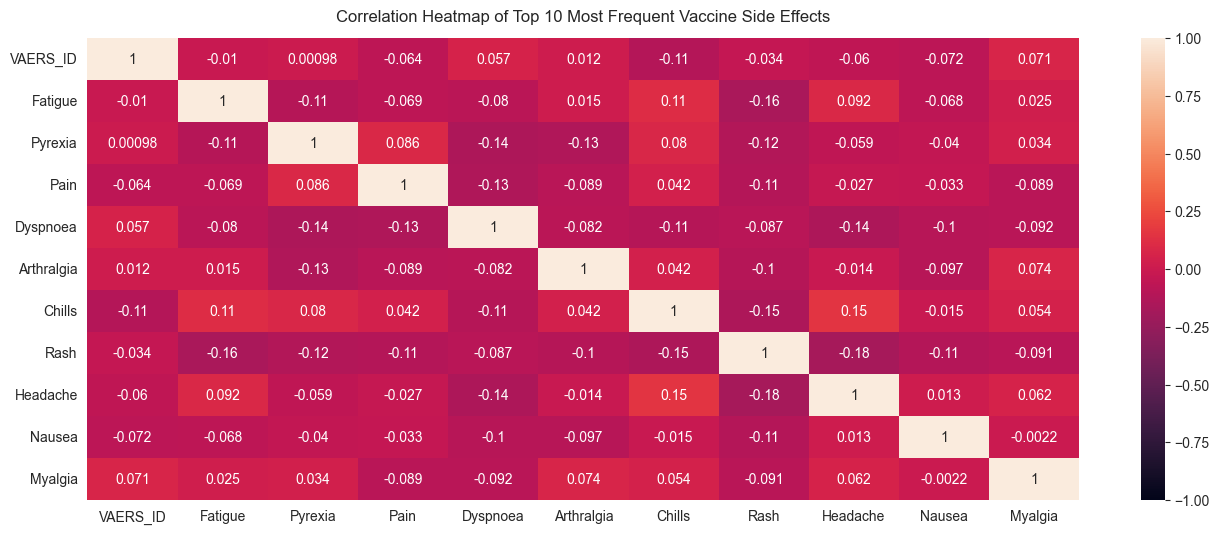

In [47]:
plt.figure(figsize=(16, 6))
heatmap = sns.heatmap(symp_all_top10_tf.corr(), vmin=-1, vmax=1, annot=True)
heatmap.set_title('Correlation Heatmap of Top 10 Most Frequent Vaccine Side Effects', fontdict={'fontsize':12}, pad=12)
plt.show()

# ANALYSIS: After assessing the provided heatmap and correlations table in the above cell, we appear to not have any correlations between many of the top 5 to 10 symptoms. It seems like the majority of experienced symptoms may either have been one-offs or paired with other types of symptoms not within our most frequent. This makes me curious about whether individual groupings (i.e., such as if specific gender identities, age groups, states, or those with allergies or history of health issues) have any symptom pairing that are most frequent or that correlate with one another in a linear or monotonic way (as it appears that something is either skewing any correlation, or there just is not one.')

# Source: WK2 Reading, https://learning.oreilly.com/library/view/exploratory-data-analysis/9781803231105/B18160_05.xhtml#_idParaDest-225

In [ ]:
### NOT SYMPTOMS-RELATED (MISC)

In [48]:
df_scatter = df_data_noliers[['VAERS_ID','NUMDAYS','HOSPDAYS']]
df_scatter = df_scatter.dropna(inplace=False, axis=0)
df_scatter.info()

<class 'pandas.DataFrame'>
Index: 19322 entries, 6 to 1012827
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   VAERS_ID  19322 non-null  int64
 1   NUMDAYS   19322 non-null  Int64
 2   HOSPDAYS  19322 non-null  Int64
dtypes: Int64(2), int64(1)
memory usage: 641.6 KB


Pearson Correlation:
           VAERS_ID   NUMDAYS  HOSPDAYS
VAERS_ID  1.000000  0.065607  0.052309
NUMDAYS   0.065607  1.000000  0.114273
HOSPDAYS  0.052309  0.114273  1.000000

Spearman Correlation:
           VAERS_ID   NUMDAYS  HOSPDAYS
VAERS_ID  1.000000  0.090400  0.064736
NUMDAYS   0.090400  1.000000  0.132044
HOSPDAYS  0.064736  0.132044  1.000000



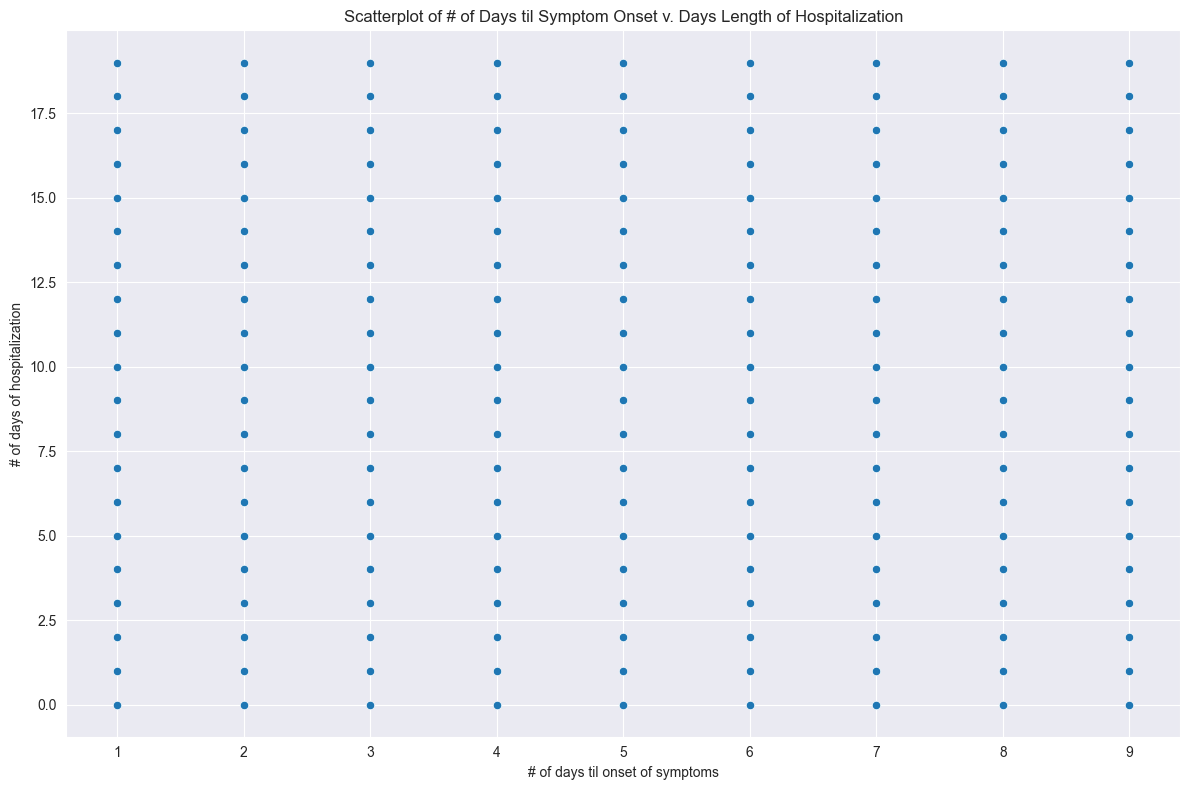

In [49]:
## Checking relationship between HOSPDAYS and NUMDAYS onset from vaccination
print(f'Pearson Correlation:\n {df_scatter.corr(method='pearson')}\n')
print(f'Spearman Correlation:\n {df_scatter.corr(method='spearman')}\n')

plt.figure(figsize= (12,8))
ax = sns.scatterplot(data = df_scatter, y= 'NUMDAYS', x= 'HOSPDAYS')
ax.set_title('Scatterplot of # of Days til Symptom Onset v. Days Length of Hospitalization', fontsize= 12)
ax.set_xlabel('# of days til onset of symptoms',fontsize = 10)
ax.set_ylabel('# of days of hospitalization',fontsize = 10)
plt.tight_layout()
plt.show()

# ANALYSIS: The number of days it takes to get symptoms has a very weak positive correlation with days spent in hospital. Getting symptoms fast doesn't correlate to longer stays. This is interesting for a couple of reasons: 1) sudden-onset cases don’t show any tendency toward longer or shorter hospitalizations, and 2) both columns lack a linear or monotonic relationship, meaning that if a relationship exists at all, it’s likely driven by non-linear or threshold effects rather than a smooth progression (as evident with the ugly scatterplot below). In other words, small changes in symptom onset don’t reliably predict hospitalization length, and immediate symptom onset does not correspond to either increased or decreased likelihood of a prolonged stay.

### Summary

**What do you think are the next steps for the team?**

The next steps for the team are to meet and compare our findings from doing EDA, clear up any confusion about the datasets (since healthcare data can get messy fast, especially if you do not have a medical background), and decide which visualizations we would want to build and test for our mock-up. From there, we can divy up the work and start putting together a dashboard we can demo to an audience.

**Is the dataset sufficient to answer the stakeholder questions, or does it need to be enriched (or even "deriched")?**

Overall, the cleaned dataset is strong enough to answer the stakeholder questions. The VAERS guide helps interpret the original fields, but the actual analysis relies on the cleaned and merged tables I already prepared. In most cases, the dataset does not need enrichment. If anything, the main challenge is deciding how much to simplify or “derich” the data so the patterns are interpretable.

**1) To measure the rates of adverse COVID-19 vaccine reactions**

The datasets are fully sufficient to answer this question. After cleaning and restructuring the symptom data, I can measure how often each reaction appears among COVID‑19 vaccine reports. My Symp_All_Top100 output already shows the most frequently reported symptoms, with headache, pyrexia, fatigue, pain, and chills at the top.

Because each symptom is tied to a VAERS_ID, and each VAERS_ID links back to demographic and vaccine information, I can also break these rates down by age, sex, manufacturer, and other variables. The heavy lifting here was with the cleaning and consolidation of the symptom fields, not adding new data. So this question is fully answerable with the dataset as it stands.

**2) To determine if rates of adverse events have changed over time (increased or decreased)**

In my view, the dataset supports this question well, and the cleaned version makes it even more workable. For instance, we have two key fields that could be leveraged for analysis: RECVDATE, which tells us when the report was received; and ONSET_DATE, which tells us when symptoms began. Both are already cleaned and aligned in the final dataset. From there, we can look at how symptom frequencies shift across different periods, such as early rollout versus later phases, or even month by month. We can also compare whether certain symptoms rise or fall over time, or whether serious outcomes cluster in particular windows. The only remaining caution is that a few outlier dates may still need to be flagged, but that is a minor cleanup step rather than a structural limitation.

For this EDA, I did not go deep into date trends; most of my time went into cleaning and restructuring the data. But the dataset itself is fully capable of supporting this type of analysis, and the necessary variables are already in place.


**3) To identify any trends in adverse events according to variables such as patient age, location (state), dosage series (i.e. shot 1 or 2), etc.**

This question is also well-supported by the cleaned dataset. We have patient age in multiple formats, state information, dose series, vaccine type, manufacturer, and all the serious outcome flags that we can use to filter symptoms. Because the tables are already merged and cleaned, I can join symptoms to demographics and vaccine details through VAERS_ID without any additional enrichment (i.e., we can use the .merge() function to link the reports by the VAERS_ID column).

From this joining, we could explore questions like whether certain symptoms are more common in specific age ranges, whether some states report different patterns, or whether dose 1 and dose 2 differ in their symptom profiles. We can also layer in other variables such as sex, facility type, or pre‑existing conditions if needed. The dataset gives us enough independent variables to explore a wide range of patterns without needing to bring in outside data.

**4) To identify the most common symptoms associated with adverse COVID-19 vaccine reactions**

This overlaps heavily with question 1. The difference is that question 1 focuses on measuring rates, which implies counts relative to the total number of reports, while question 4 focuses on ranking symptoms by frequency. In practice, both questions rely on the same cleaned symptom dataset and the same grouping logic. So question 4 is essentially a subset of the work already done for question 1.

If we wanted to extend this question, we could move beyond simple frequency and look at how common symptoms appear together. For example, in the correlations section, I found that the top 10 most common symptoms do not meaningfully co-occur. Their pairwise relationships are essentially flat, giving us a sense of how to interpret the group (and in general, the most common symptoms). It just gives

**What should people look for in terms of mining data? Any relationships or correlations to discuss?**

As we have identified, we are trying to predict and understand symptoms. In this EDA, I did not have the time to dig into how symptoms relate to basic demographic differences, but now that the dataset is fully cleaned, this is something we can explore. Since symptoms function as our dependent variable, the interesting work comes from looking at how different independent variables shape or predict the types of symptoms that get reported. The cleaned dataset gives us a lot of room to explore these relationships. When it comes to mining specific relationships or correlation patterns, I would look into the following:

**• Demographics:** Whether certain symptoms appear more often in specific age groups or differ between men and women. For example, younger recipients might report more systemic reactions like fever or chills, while older recipients might show different patterns.

**• Manufacturer or vaccine type differences:** Since each VAERS_ID links to vaccine type and manufacturer, we can explore whether symptom patterns differ across products. Again, this is descriptive rather than causal, but still a valid relationship to mine.

**• Serious outcome flags (a.k.a "the bools"):** Variables like hospitalization, disability, or life‑threatening events can help us see whether certain symptoms tend to co‑occur with more severe outcomes.

In my current view, the cleaned dataset is structured well for this kind of mining, and most of the interesting relationships could come from grouping, filtering, and comparing symptom distributions across these different dimensions. I don't think we need to look externally or elsewhere for more data; I think the three datasets have ample information to helping ascertain the questions presented by our stakeholders.

**What story should your team be telling**

The story we should be telling starts with the reality that vaccine skepticism is high and trust in public health institutions is uneven. People hear a lot of claims about vaccines causing serious harm, and the conversation often gets shaped by fear instead of data. That skepticism can also affect the people who manage or oversee vaccine distribution, many of whom do not have a medical background and may not know how to separate reasonable side effects from misinformation.

Our role is to use the cleaned VAERS dataset to show what the reported reactions actually look like in a way that is open, honest, and easy for anyone to understand. The goal is not to argue that vaccines are flawless. It is to show the real distribution of onset side effects, highlight how common the mild ones are, and give a clear view of how rare the serious ones tend to be. When people can see the data directly, it becomes harder for misinformation to fill in the gaps.

This clarity also helps people inside the healthcare system. Managers, administrators, and vaccine developers all need a grounded picture of what is happening. They need to know whether certain symptoms are appearing more often than expected, whether patterns shift across age or dose, and whether anything in the data signals a need for attention.

In the end, the story we should be telling is one of transparency. "Here is what people reported. Here is how often these reactions appear. Here is how the patterns change across different groups." This aim is to give people a realistic, data‑driven understanding of adverse reactions and to replace speculation with something they can actually trust.

**What recommendations do you have for dashboard models? Any KPIs? Specific visualizations?**

**_Visualizations Recommendations_**

• Users should be able to toggle any of the boolean or categorical fields and immediately see how the symptom distribution changes. For example, turning the “allergies” flag on should update the bar chart of most common symptoms so users can compare that subgroup to the overall population.

• A possible interactive US map would be useful for showing which states report the most reactions. Clicking a state could open a small panel with summary stats like total reports, top symptoms, and proportion of serious outcomes. This helps users spot regional reporting patterns or outliers.

• A line chart showing how the frequency of top symptoms changes over time could be a neat addition as well. This could help identify reporting spikes, rollout phases, or seasonal patterns.

• Some sort of relationship visualization that shows common symptoms that are paired together. For instance, do we often see headaches as a symptom reported with pyrexia? I'm not sure which visualization would be the best for this at the moment, but it is something we may wanna include in the dashboard.

_**KPI Recommendations (dynamic counts and numerical information that changes with "the bool filtering system")**_

• A basic count of how many people reported some sort of onset of symptoms with vaccination.

• Percentage of serious reports (i.e., those hospitalized, those that died, etc.)

• Mean, median, and mode of onset time (i.e., number of days it took for symptoms to onset and how that changes per filter).


**Any confusions or unknowns that need to be explored?**

One variable that still does not make full sense to me is VAX_LOT. I understand it is supposed to represent the manufacturer’s lot number, but I am not fully confident about how it should be interpreted or used analytically. I need to confirm this with my group before making assumptions about its meaning or relevance.

Also, in VAERSDATA, we have these open-ended sections that I'd like to convert to bools. For instance, it would be nice to have a simple true/false column that marked whether someone had an allergy or not. However, this is difficult to do, since in the open-ended, people would write "no allergies" or "none" as a response, instead of leaving the section blank. This makes creating a true an accurate bool very difficult (and it even makes me question if it is even possible to complete for this class, in a timely manner).

I also still have some questions about how VAERS_ID works across the three datasets. It is not immediately obvious why duplicates are acceptable in some files but not in others. Based on the data dictionary, my current understanding is that certain tables allow multiple rows per VAERS_ID because they capture additional information that cannot fit into a single record. For example, VAERSSYMPTOMS only stores up to five symptoms per row, so if a report includes more than five symptoms, it creates another row with the same VAERS_ID. This makes sense conceptually, but I want to confirm this interpretation with my group to make sure I am not missing anything.

More broadly, and at least for myself, the relationship between the three datasets is not completely straightforward. VAERS_ID is the only link, but the tables are not aligned row by row, and not every VAERS_ID appears in every file. This means we cannot simply merge everything into one giant table without thinking carefully about the structure and the meaning of each merge.

Finally, I am still unsure about the best way to visualize relationships involving symptoms. There are so many possible symptoms in the dataset that it becomes difficult to choose a single visualization that captures the patterns cleanly. This might just require more discussion with "the squad", but at this very moment, it remains a mystery for myself on how we can show this information in the most efficient way possible.

**Do you feel like you have a better understanding of the dataset now? Do you feel better prepared to work with your teammates to make a dashboard of this data? Why or why not?**

I definitely have a much stronger understanding of the dataset now, then when I did earlier. Prior to this deliverable, I had no real sense of what vaccine data actually looked like, or even how detailed it could get when it came to the onset of symptoms. Working through the EDA gave me so much more of a clearer picture of what actually gets reported in vaccine data. For instance, I learned about the most common symptoms with vaccination, the relevance of where a vaccine is administered on the body, and even the different methods of administration. Exploring and cleaning up all boolean fields even jogged up some ideas in how we can visualize all this information for our shareholders. Doing the EDA basically just made things "click" for me.

In short, I do feel now prepared to work with my teammates on this dashboard. I spent time exploring all three datasets, understanding how they connect, and figuring out which columns actually matter for our analysis. I even went through the data dictionary to make sure I understood what each field meant and how it should be cleaned or used. That work gave me a clearer mental model of the dataset, which will make it much easier to collaborate with the group and help shape a dashboard that tells the right story. I think clearing any remaining uncertainties and areas where I am second-guessing myself will just further improve my prep, confidence, and knowledge, when it comes to this dataset.

In [ ]:
# Just making sure my poetry file(s) are up to date.
!poetry lock